Libraries

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, roc_auc_score,
                             accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

print(' Libraries imported!')
print(f'TensorFlow: {tf.__version__}')

 Libraries imported!
TensorFlow: 2.21.0


Loading Data

In [2]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_train = np.load(f'{path}\\X_train_images.npy')
X_val   = np.load(f'{path}\\X_val_images.npy')
X_test  = np.load(f'{path}\\X_test_images.npy')
y_train = np.load(f'{path}\\y_train_images.npy')
y_val   = np.load(f'{path}\\y_val_images.npy')
y_test  = np.load(f'{path}\\y_test_images.npy')

print(' Data loaded!')
print(f'X_train : {X_train.shape}')
print(f'Classes before: {np.unique(y_train)}')

 Data loaded!
X_train : (4480, 128, 128, 3)
Classes before: [0 1 2 3]


Converting 4 Classes to 2 Classes

In [3]:
# 4 classes → 2 classes
# 0 = MildDemented     → 1 (Demented)
# 1 = ModerateDemented → 1 (Demented)
# 2 = NonDemented      → 0 (Normal)
# 3 = VeryMildDemented → 1 (Demented)

def convert_to_binary(labels):
    binary = np.where(labels == 2, 0, 1)
    return binary

y_train_bin = convert_to_binary(y_train)
y_val_bin   = convert_to_binary(y_val)
y_test_bin  = convert_to_binary(y_test)

print(' Converted to Binary!')
print(f'\nBefore conversion:')
unique, counts = np.unique(y_train, return_counts=True)
classes_4 = ['MildDemented', 'ModerateDemented',
             'NonDemented', 'VeryMildDemented']
for u, c in zip(unique, counts):
    print(f'  {classes_4[u]}: {c}')

print(f'\nAfter conversion:')
unique_bin, counts_bin = np.unique(
    y_train_bin, return_counts=True
)
classes_2 = ['NonDemented (0)', 'Demented (1)']
for u, c in zip(unique_bin, counts_bin):
    print(f'  {classes_2[u]}: {c}')

 Converted to Binary!

Before conversion:
  MildDemented: 627
  ModerateDemented: 45
  NonDemented: 2240
  VeryMildDemented: 1568

After conversion:
  NonDemented (0): 2240
  Demented (1): 2240


Class Distribution Chart

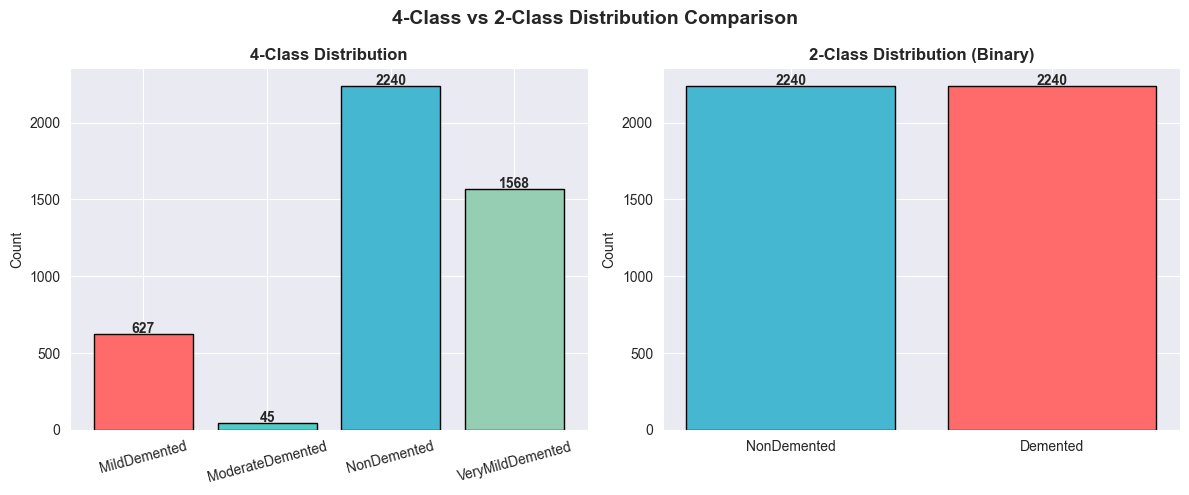

 Distribution chart saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 4 class
unique4, counts4 = np.unique(y_train,
                              return_counts=True)
axes[0].bar(
    [classes_4[i] for i in unique4],
    counts4,
    color=['#FF6B6B', '#4ECDC4',
           '#45B7D1', '#96CEB4'],
    edgecolor='black'
)
axes[0].set_title('4-Class Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(counts4):
    axes[0].text(i, v + 5, str(v),
                 ha='center', fontweight='bold')

# 2 class
unique2, counts2 = np.unique(y_train_bin,
                              return_counts=True)
axes[1].bar(
    ['NonDemented', 'Demented'],
    counts2,
    color=['#45B7D1', '#FF6B6B'],
    edgecolor='black'
)
axes[1].set_title('2-Class Distribution (Binary)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts2):
    axes[1].text(i, v + 5, str(v),
                 ha='center', fontweight='bold')

plt.suptitle(
    '4-Class vs 2-Class Distribution Comparison',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('binary_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Distribution chart saved!')

Class Weights

In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_bin),
    y=y_train_bin
)
class_weight_dict = dict(enumerate(class_weights))

print(' Class Weights:')
print(f'  NonDemented : {class_weights[0]:.3f}')
print(f'  Demented    : {class_weights[1]:.3f}')

 Class Weights:
  NonDemented : 1.000
  Demented    : 1.000


VGG16 Model for 2 Classes

import pandas as pd

comparison = pd.DataFrame({
    'Approach' : [
        '4-Class CNN',
        '4-Class VGG16',
        '2-Class CNN',
        '2-Class VGG16'
    ],
    'Classes'  : [4, 4, 2, 2],
    'Accuracy' : [
        56.67, 75.94,
        67.92,
        round(acc*100, 2)
    ],
    'F1-Score' : [
        56.51, 76.11,
        67.92,
        round(f1*100, 2)
    ],
    'ROC-AUC'  : [
        72.50, 90.83,
        73.54,
        round(auc*100, 2)
    ]
})

print('=' * 62)
print('  Complete Image Model Comparison')
print('=' * 62)
print(comparison.to_string(index=False))
print('=' * 62)

# Improvement calculate karo
cnn_improvement = round(acc*100, 2) - 56.67
vgg_improvement = round(acc*100, 2) - 75.94

print(f'\n📈 Improvement from 4-Class CNN:')
print(f'   +{cnn_improvement:.2f}%')
print(f'\n📈 vs 4-Class VGG16:')
print(f'   {vgg_improvement:+.2f}%')

comparison.to_csv(
    f'{save_path}\\final_image_comparison.csv',
    index=False
)

print('\n✅ VGG16 Binary Complete!')
print('Next → Report!')Model

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# VGG16 base load
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Pehle sab freeze
base_model.trainable = False

# Last 4 layers unfreeze
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Top layers add karo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Binary output — sigmoid!
output = Dense(1, activation='sigmoid')(x)

model_cnn = Model(
    inputs=base_model.input,
    outputs=output
)

model_cnn.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'Total layers     : {len(model_cnn.layers)}')
print(f'Trainable layers : '
      f'{len([l for l in model_cnn.layers if l.trainable])}')
print(f'Frozen layers    : '
      f'{len([l for l in model_cnn.layers if not l.trainable])}')
print(' VGG16 Binary Model ready!')

Total layers     : 26
Trainable layers : 11
Frozen layers    : 15
 VGG16 Binary Model ready!


Callbacks

In [7]:
save_path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{save_path}\\best_binary_vgg16.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(' Callbacks ready!')

 Callbacks ready!


Training

In [8]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

datagen.fit(X_train)

print('Training Binary CNN...')

history = model_cnn.fit(
    datagen.flow(X_train, y_train_bin,
                 batch_size=64),
    validation_data=(X_val, y_val_bin),
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(' Training complete!')

Training Binary CNN...
Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5545 - loss: 0.7111
Epoch 1: val_accuracy improved from None to 0.50000, saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_binary_vgg16.keras

Epoch 1: finished saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_binary_vgg16.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.5902 - loss: 0.6812 - val_accuracy: 0.5000 - val_loss: 0.6853
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6448 - loss: 0.6311
Epoch 2: val_accuracy improved from 0.50000 to 0.52292, saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_binary_vgg16.keras

Epoch 2: finished saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_binary_vgg16.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.6558 - loss: 0.6266 - 

Training Graphs

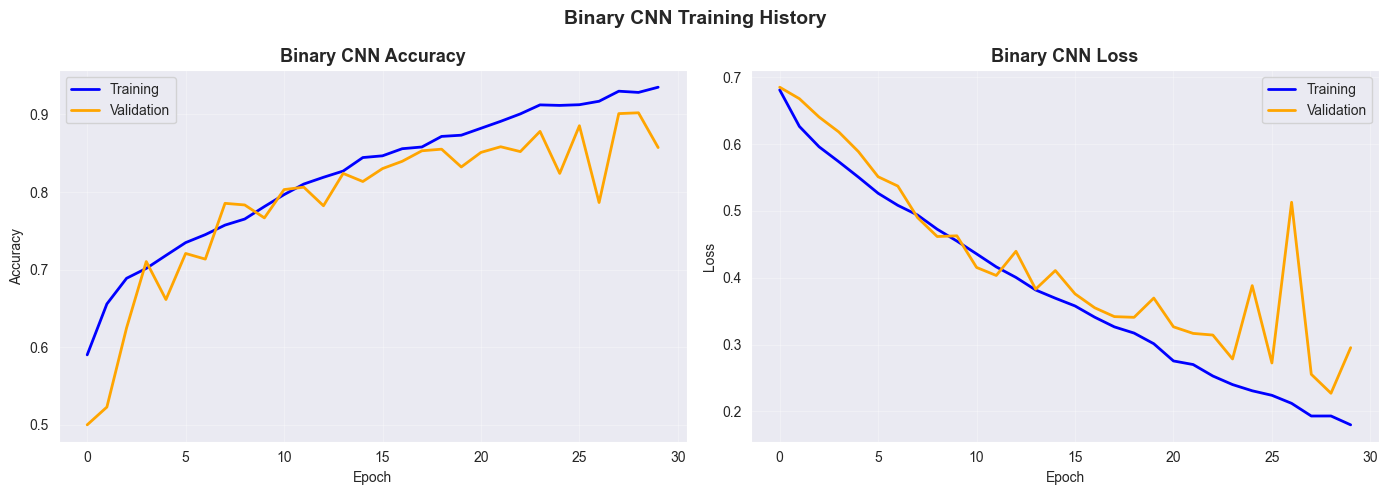

 Graph saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],
             label='Training',
             color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation',
             color='orange', linewidth=2)
axes[0].set_title('Binary CNN Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],
             label='Training',
             color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation',
             color='orange', linewidth=2)
axes[1].set_title('Binary CNN Loss',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Binary CNN Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_cnn_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Graph saved!')

Evaluate

In [10]:
y_pred_prob = model_cnn.predict(X_test).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test_bin, y_pred)
f1  = f1_score(y_test_bin, y_pred,
               average='weighted')
auc = roc_auc_score(y_test_bin, y_pred_prob)

print('=' * 50)
print('  BINARY CNN — FINAL RESULTS')
print('=' * 50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1-Score : {f1*100:.2f}%')
print(f'ROC-AUC  : {auc*100:.2f}%')
print('=' * 50)

30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step
  BINARY CNN — FINAL RESULTS
Accuracy : 91.46%
F1-Score : 91.45%
ROC-AUC  : 97.47%


Confusion Matrix

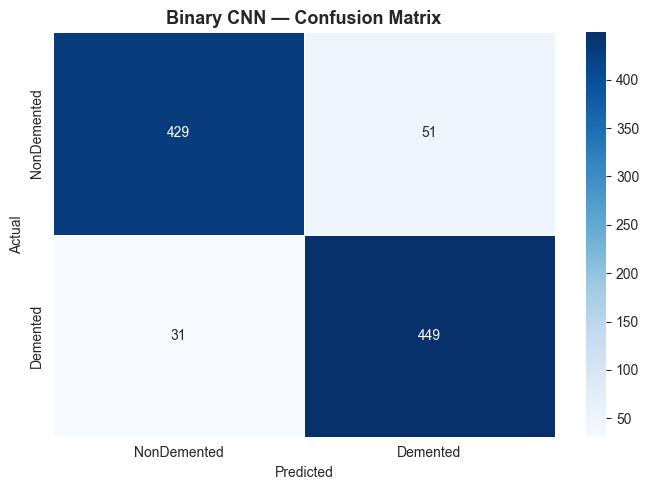

 Saved!


In [11]:
cm = confusion_matrix(y_test_bin, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['NonDemented',
                         'Demented'],
            yticklabels=['NonDemented',
                         'Demented'],
            linewidths=0.5)

plt.title('Binary CNN — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('binary_cnn_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved!')

Classification Report

In [12]:
print('Classification Report:')
print('=' * 45)
print(classification_report(
    y_test_bin, y_pred,
    target_names=['NonDemented', 'Demented']
))

Classification Report:
              precision    recall  f1-score   support

 NonDemented       0.93      0.89      0.91       480
    Demented       0.90      0.94      0.92       480

    accuracy                           0.91       960
   macro avg       0.92      0.91      0.91       960
weighted avg       0.92      0.91      0.91       960


4 Classes vs 2 Classes

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    'Approach' : [
        '4-Class CNN',
        '4-Class VGG16',
        '2-Class CNN',
        '2-Class VGG16'
    ],
    'Classes'  : [4, 4, 2, 2],
    'Accuracy' : [
        56.67, 75.94,
        67.92,
        round(acc*100, 2)
    ],
    'F1-Score' : [
        56.51, 76.11,
        67.92,
        round(f1*100, 2)
    ],
    'ROC-AUC'  : [
        72.50, 90.83,
        73.54,
        round(auc*100, 2)
    ]
})

print('=' * 62)
print('  Complete Image Model Comparison')
print('=' * 62)
print(comparison.to_string(index=False))
print('=' * 62)

# Improvement calculate karo
cnn_improvement = round(acc*100, 2) - 56.67
vgg_improvement = round(acc*100, 2) - 75.94

print(f'\n Improvement from 4-Class CNN:')
print(f'   +{cnn_improvement:.2f}%')
print(f'\n vs 4-Class VGG16:')
print(f'   {vgg_improvement:+.2f}%')

comparison.to_csv(
    f'{save_path}\\final_image_comparison.csv',
    index=False
)

print('\n VGG16 Binary Complete!')
print('Next → Report!')

  Complete Image Model Comparison
     Approach  Classes  Accuracy  F1-Score  ROC-AUC
  4-Class CNN        4     56.67     56.51    72.50
4-Class VGG16        4     75.94     76.11    90.83
  2-Class CNN        2     67.92     67.92    73.54
2-Class VGG16        2     91.46     91.45    97.47

📈 Improvement from 4-Class CNN:
   +34.79%

📈 vs 4-Class VGG16:
   +15.52%

 VGG16 Binary Complete!
Next → Report!
